# Preparing the Drought Dataset — Eastern Croatia

This notebook handles all raw data work:
1. Load ERA5-Land monthly means (NetCDF4)
2. Load ESA CCI satellite soil moisture (ZIP of 264 monthly files)
3. Crop to Eastern Croatia, align grids, merge into one DataFrame
4. Compute improved drought labels using depth-weighted root-zone soil moisture
   with 3-month smoothing (SSI-3 methodology)
5. Save the ready dataset to `data/dataset.csv`


In [1]:
import warnings, zipfile, io
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

# ── Directories ───────────────────────────────────────────────────────────────
DATA_DIR  = Path("data")
PLOTS_DIR = Path("plots")
for d in [DATA_DIR, PLOTS_DIR]:
    d.mkdir(exist_ok=True)

# ── Raw data files ────────────────────────────────────────────────────────────
ERA5_FILE = DATA_DIR / "era5_land.nc"
SAT_FILE  = DATA_DIR / "satellite_sm.nc"

# ── Study area: Eastern Croatia (Slavonia) ───────────────────────────────────
LAT_MIN, LAT_MAX = 45.0, 45.8
LON_MIN, LON_MAX = 17.5, 19.0

print("Setup complete.")
print(f"  ERA5 file exists:   {ERA5_FILE.exists()}")
print(f"  Sat SM file exists: {SAT_FILE.exists()}")


Setup complete.
  ERA5 file exists:   True
  Sat SM file exists: True


---
## Step 1 — Load ERA5-Land


In [ ]:
# engine='h5netcdf' avoids a Windows bug where the netCDF4 C library
ds_era5 = xr.open_dataset(ERA5_FILE, engine="h5netcdf")

# ERA5 uses 'latitude', 'longitude', 'valid_time' — rename to lat/lon/time
rename = {}
if "latitude"   in ds_era5.coords: rename["latitude"]   = "lat"
if "longitude"  in ds_era5.coords: rename["longitude"]  = "lon"
if "valid_time" in ds_era5.coords: rename["valid_time"] = "time"
ds_era5 = ds_era5.rename(rename)

# Drop non-essential coordinate metadata
for drop in ["number", "expver"]:
    if drop in ds_era5.coords:
        ds_era5 = ds_era5.drop_vars(drop)

# Snap time to first-of-month timestamps (monthly data)
times = pd.to_datetime(ds_era5.time.values)
ds_era5 = ds_era5.assign_coords(
    time=pd.PeriodIndex(times, freq="M").to_timestamp()
)

# Ensure latitude is ascending (south → north)
if ds_era5.lat[0] > ds_era5.lat[-1]:
    ds_era5 = ds_era5.isel(lat=slice(None, None, -1))

print("ERA5-Land loaded:")
print(f"  dims : {dict(ds_era5.sizes)}")
print(f"  vars : {list(ds_era5.data_vars)}")
print(f"  time : {pd.Timestamp(ds_era5.time.values[0]).date()}"
      f" → {pd.Timestamp(ds_era5.time.values[-1]).date()}")


ERA5-Land loaded:
  dims : {'time': 264, 'lat': 9, 'lon': 16}
  vars : ['d2m', 't2m', 'swvl1', 'swvl2', 'swvl3', 'swvl4', 'ssr', 'pev', 'e', 'tp']
  time : 2003-01-01 → 2024-12-01


---
## Step 2 — Load Satellite Soil Moisture


In [3]:
# The satellite SM download is a ZIP containing 264 individual monthly NetCDF4
# files (one per month, global coverage). We read each file directly from the
# ZIP into memory using BytesIO — no extraction needed — and crop to the
# bounding box immediately to keep memory usage small.

print("Reading satellite SM from ZIP (264 files) …")
sat_slices = []
with zipfile.ZipFile(SAT_FILE, "r") as z:
    for fname in sorted(z.namelist()):
        raw = z.read(fname)
        ds  = xr.open_dataset(io.BytesIO(raw), engine="h5netcdf")
        # Latitude is descending in these files → slice(MAX, MIN)
        ds  = ds[["sm"]].sel(
            lat=slice(LAT_MAX, LAT_MIN),
            lon=slice(LON_MIN, LON_MAX),
        )
        sat_slices.append(ds)

ds_sat = xr.concat(sat_slices, dim="time")

# Snap time to monthly timestamps
times_sat = pd.to_datetime(ds_sat.time.values)
ds_sat = ds_sat.assign_coords(
    time=pd.PeriodIndex(times_sat, freq="M").to_timestamp()
)

print("Satellite SM loaded:")
print(f"  dims : {dict(ds_sat.sizes)}")
print(f"  time : {pd.Timestamp(ds_sat.time.values[0]).date()}"
      f" → {pd.Timestamp(ds_sat.time.values[-1]).date()}")


Reading satellite SM from ZIP (264 files) …
Satellite SM loaded:
  dims : {'time': 264, 'lat': 3, 'lon': 6}
  time : 2003-01-01 → 2024-12-01


---
## Step 3 — Align Grids & Merge


In [4]:
# Keep only months present in both datasets
common_times = np.intersect1d(ds_era5.time.values, ds_sat.time.values)
ds_era5 = ds_era5.sel(time=common_times)
ds_sat  = ds_sat.sel(time=common_times)
print(f"Common months: {len(common_times)}")

# ERA5 is 0.1° resolution, satellite SM is 0.25° (native sensor resolution).
# Nearest-neighbour interpolation maps each ERA5 cell to the closest sat cell.
# This is standard practice — no higher-resolution satellite product exists.
ds_sat_regrid = ds_sat.interp(
    lat=ds_era5.lat.values,
    lon=ds_era5.lon.values,
    method="nearest",
)
print(f"Satellite SM regridded to ERA5 grid: {dict(ds_sat_regrid.sizes)}")


Common months: 264
Satellite SM regridded to ERA5 grid: {'time': 264, 'lat': 9, 'lon': 16}


In [5]:
# Convert both datasets to flat DataFrames and merge on time + lat + lon
print("Merging into flat DataFrame …")

df_era5 = ds_era5.to_dataframe().reset_index()
df_sat  = (ds_sat_regrid[["sm"]]
           .to_dataframe()
           .reset_index()
           .rename(columns={"sm": "sat_sm"}))

df = df_era5.merge(df_sat, on=["time", "lat", "lon"], how="left")

# Drop rows where all soil water columns are NaN (should not occur for this region)
swvl_cols = [c for c in df.columns if c.startswith("swvl")]
df = df.dropna(subset=swvl_cols, how="all")

# Fill any remaining NaNs with column medians
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["time", "lat", "lon"]).reset_index(drop=True)

print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


Merging into flat DataFrame …
DataFrame shape: (38016, 14)
Columns: ['time', 'lat', 'lon', 'd2m', 't2m', 'swvl1', 'swvl2', 'swvl3', 'swvl4', 'ssr', 'pev', 'e', 'tp', 'sat_sm']


---
## Step 4 — Compute Drought Labels (SSI-3 Methodology)


1. **Root-zone weighted moisture** — combines swvl1, swvl2, swvl3 weighted by
   layer thickness (7 cm, 21 cm, 72 cm). Agriculture depends on root-zone water,
   not just the surface 7 cm.

2. **3-month smoothing** — a rolling 3-month mean removes short-term noise.
   Crops respond to sustained deficit, not a single dry month.
   This follows the SSI-3 (Standardised Soil-moisture Index, 3-month) approach
   used in WMO drought monitoring and the Copernicus Climate Change Service.

3. **2-month ahead target** — features from month T predict drought at month T+2,
   giving farmers actionable lead time before the growing season.


In [6]:
df["month"] = df["time"].dt.month
df = df.sort_values(["lat", "lon", "time"]).reset_index(drop=True)

# ── Step 1: depth-weighted root zone soil moisture ────────────────────────────
# swvl1: 0–7 cm   (weight 7/100  = 0.07)
# swvl2: 7–28 cm  (weight 21/100 = 0.21)
# swvl3: 28–100cm (weight 72/100 = 0.72)
df["sm_rootzone"] = (
    0.07 * df["swvl1"] +
    0.21 * df["swvl2"] +
    0.72 * df["swvl3"]
)

# ── Step 2: 3-month rolling average per grid cell (SSI-3 smoothing) ───────────
df["sm_smooth"] = (
    df.groupby(["lat", "lon"])["sm_rootzone"]
      .transform(lambda x: x.rolling(3, min_periods=2).mean())
)

# ── Step 3: long-term monthly climatology of the smoothed value ───────────────
clim = (
    df.groupby(["lat", "lon", "month"])["sm_smooth"]
      .agg(clim_mean="mean", clim_std="std")
      .reset_index()
)
clim["clim_std"] = clim["clim_std"].replace(0, 1e-6)
df = df.merge(clim, on=["lat", "lon", "month"], how="left")

# ── Step 4: standardised anomaly ─────────────────────────────────────────────
# Positive = wetter than normal, negative = drier than normal
df["sm_anomaly"] = (df["sm_smooth"] - df["clim_mean"]) / df["clim_std"]

# ── Step 5: binary drought label for the current month ───────────────────────
df["drought_binary"] = (df["sm_anomaly"] < -0.5).astype(int)

# ── Step 6: shift 2 months forward per grid cell ─────────────────────────────
# Input features = conditions observed this month
# Target         = will there be drought 2 months from now?
df["drought_2months"] = (
    df.groupby(["lat", "lon"])["drought_binary"]
      .shift(-2)
)
df = df.dropna(subset=["drought_2months"])
df["drought_2months"] = df["drought_2months"].astype(int)

print("Drought label distribution (2-month ahead target):")
print(df["drought_2months"].value_counts().rename({0: "Normal", 1: "Drought"}))
print(f"\nDrought fraction: {df['drought_2months'].mean():.1%}")
print(f"Final dataset shape: {df.shape}")


Drought label distribution (2-month ahead target):
drought_2months
Normal     25196
Drought    12532
Name: count, dtype: int64

Drought fraction: 33.2%
Final dataset shape: (37728, 22)


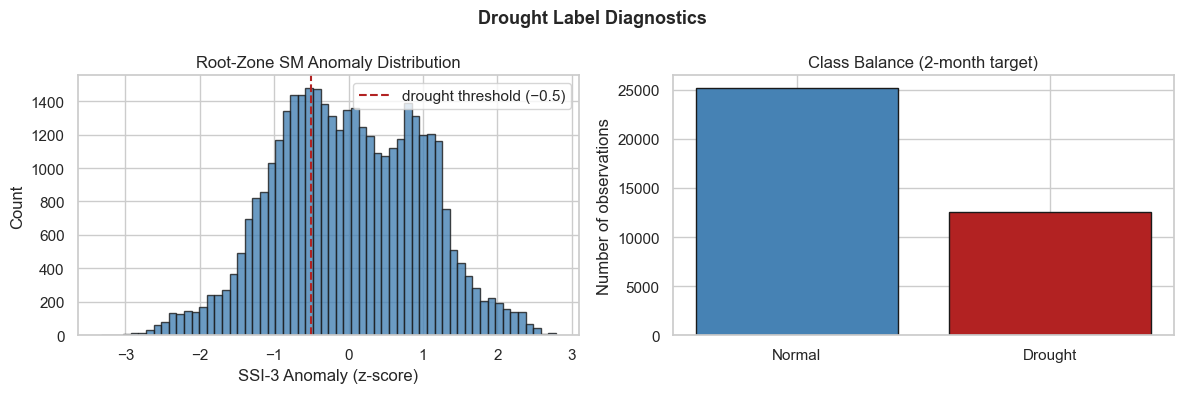

Saved: plots/class_balance.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Drought Label Diagnostics", fontsize=13, fontweight="bold")

# Anomaly distribution
axes[0].hist(df["sm_anomaly"], bins=60, color="steelblue",
             edgecolor="k", alpha=0.8)
axes[0].axvline(-0.5, color="firebrick", linestyle="--",
                label="drought threshold (−0.5)")
axes[0].set_xlabel("SSI-3 Anomaly (z-score)")
axes[0].set_ylabel("Count")
axes[0].set_title("Root-Zone SM Anomaly Distribution")
axes[0].legend()

# Class balance
counts = df["drought_2months"].value_counts().sort_index()
axes[1].bar(["Normal", "Drought"], counts.values,
            color=["steelblue", "firebrick"], edgecolor="k")
axes[1].set_title("Class Balance (2-month target)")
axes[1].set_ylabel("Number of observations")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "class_balance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plots/class_balance.png")


---
## Step 5 — Feature Engineering

Features added:
- **Lagged soil moisture**: swvl1 at t−1, t−2, t−3 months (momentum signal)
- **3-month rolling mean** of precipitation and temperature (trend signal)
- **Precipitation deficit**: current tp minus long-term monthly mean tp


In [8]:
df = df.sort_values(["lat", "lon", "time"]).reset_index(drop=True)

def add_lags_and_rolling(group):
    """Compute lag and rolling features per grid cell."""
    g = group.copy()
    for lag in [1, 2, 3]:
        g[f"swvl1_lag{lag}"] = g["swvl1"].shift(lag)
    g["tp_roll3"]  = g["tp"].shift(1).rolling(3, min_periods=1).mean()
    g["t2m_roll3"] = g["t2m"].shift(1).rolling(3, min_periods=1).mean()
    return g

print("Computing lag and rolling features per grid cell …")
df = df.groupby(["lat", "lon"], group_keys=False).apply(add_lags_and_rolling)

# Precipitation deficit: current month vs long-term monthly mean
tp_clim = (
    df.groupby(["lat", "lon", "month"])["tp"]
      .mean()
      .reset_index()
      .rename(columns={"tp": "tp_clim_mean"})
)
df = df.merge(tp_clim, on=["lat", "lon", "month"], how="left")
df["tp_deficit"] = df["tp"] - df["tp_clim_mean"]

# Drop rows with NaN from lagging (first 1-3 months per grid cell)
df = df.dropna().reset_index(drop=True)

print(f"Shape after feature engineering: {df.shape}")
print("Feature columns added:", ["swvl1_lag1","swvl1_lag2","swvl1_lag3",
                                   "tp_roll3","t2m_roll3","tp_deficit"])


Computing lag and rolling features per grid cell …
Shape after feature engineering: (37296, 29)
Feature columns added: ['swvl1_lag1', 'swvl1_lag2', 'swvl1_lag3', 'tp_roll3', 't2m_roll3', 'tp_deficit']


---
## Step 6 — Save Dataset


In [9]:
OUT = DATA_DIR / "dataset.csv"
df.to_csv(OUT, index=False)
print(f"Dataset saved → {OUT}")
print(f"  Rows    : {len(df):,}")
print(f"  Columns : {list(df.columns)}")
print("\nRun drought_prediction.ipynb next.")


Dataset saved → data\dataset.csv
  Rows    : 37,296
  Columns : ['time', 'lat', 'lon', 'd2m', 't2m', 'swvl1', 'swvl2', 'swvl3', 'swvl4', 'ssr', 'pev', 'e', 'tp', 'sat_sm', 'month', 'sm_rootzone', 'sm_smooth', 'clim_mean', 'clim_std', 'sm_anomaly', 'drought_binary', 'drought_2months', 'swvl1_lag1', 'swvl1_lag2', 'swvl1_lag3', 'tp_roll3', 't2m_roll3', 'tp_clim_mean', 'tp_deficit']

Run drought_prediction.ipynb next.
